<a href="https://colab.research.google.com/github/nathannguyen13/A01-data-wrangling/blob/main/notebook_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Nguyen

**Date:** 9/11/26

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [1]:
! git clone https://github.com/nathannguyen13/A02-eda-and-visualization

Cloning into 'A02-eda-and-visualization'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 6 (from 1)
Receiving objects: 100% (10/10), 1.19 MiB | 7.50 MiB/s, done.


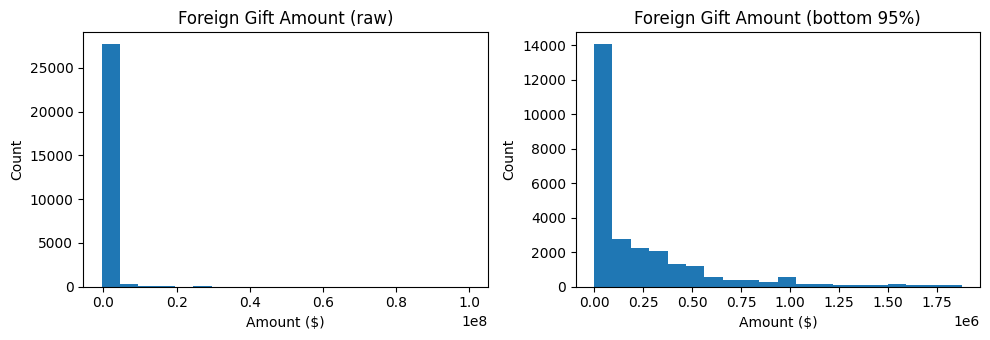

In [9]:
#1-2

df = pd.read_csv('A02-eda-and-visualization/data/ForeignGifts_edu.csv', low_memory=False)


fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[0])
axes[0].set(title="Foreign Gift Amount (raw)", xlabel="Amount ($)", ylabel="Count")
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[1], range=(0, df["Foreign Gift Amount"].quantile(0.95)))
axes[1].set(title="Foreign Gift Amount (bottom 95%)", xlabel="Amount ($)", ylabel="Count")
plt.tight_layout()
plt.show()

Foreign Gift Amount is heavily right-skewed. Zooming into the bottom 95% of values shows most gifts fall under $2M, concentrated mainly below a few hundred thousand dollars.

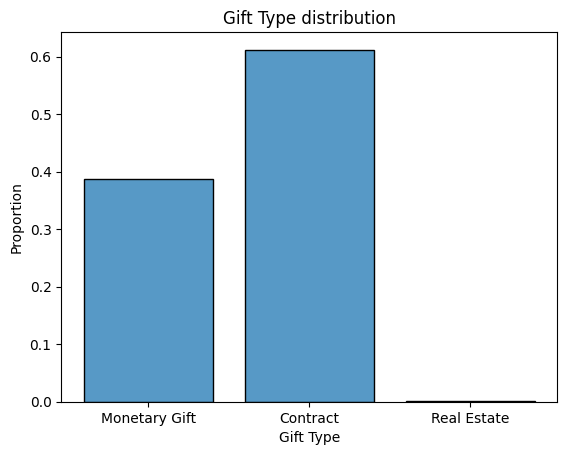

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [13]:
#3
df = pd.read_csv('A02-eda-and-visualization/data/ForeignGifts_edu.csv', low_memory=False)


ax = sns.histplot(x=df["Gift Type"], stat="proportion", discrete=True, shrink=0.8)
ax.set(title="Gift Type distribution", xlabel="Gift Type", ylabel="Proportion")
plt.show()

df["Gift Type"].value_counts()
df["Gift Type"].value_counts(normalize=True)

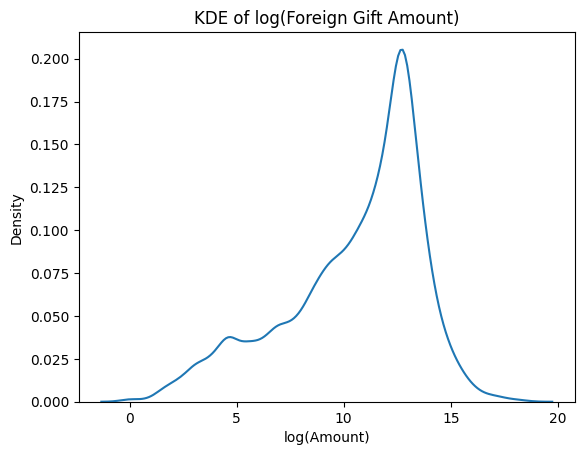

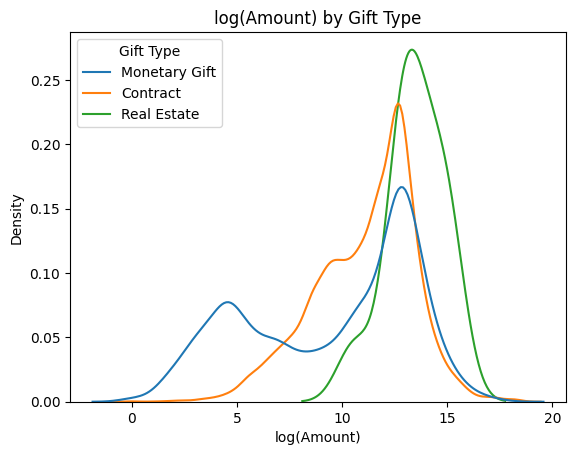

In [19]:
#4

ax = sns.kdeplot(x=pos["log_amount"], bw_method="silverman")
ax.set(title="KDE of log(Foreign Gift Amount)", xlabel="log(Amount)", ylabel="Density")
plt.show()

ax = sns.kdeplot(data=pos, x="log_amount", hue="Gift Type", common_norm=False)
ax.set(title="log(Amount) by Gift Type", xlabel="log(Amount)", ylabel="Density")
plt.show()

Contracts bunch up more toward the middle/higher end, while Monetary Gifts spread out more and have a lot more small ones too, kind of a double bump. Real Estate is way over to the right but there's barely any of those.

In [26]:
#5
print(df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending=False).head(15))

print(df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [27]:
#6

df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


Qatar Foundation gives the most overall (about $1.17B across 261 gifts).

---

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]